# Metrics Table by Dataset and Action

This notebook loads `results/all_models_metrics_long.csv`, filters rows by `dataset` and `action_filter`, and displays a styled table where the best value for each metric is highlighted in green and the second best in amber.

`APD` is treated as higher-is-better. The other displayed metrics are treated as lower-is-better.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display

CSV_PATH = Path('/home/fagnelli/diffusion_hands/results/all_models_metrics_long.csv')
METRIC_COLUMNS = [
    'APD',
    'ADE',
    'FDE',
    'MMADE',
    'MMFDE',
    'CMD',
    'FID',
]
HIGHER_IS_BETTER = {'APD'}

df = pd.read_csv(CSV_PATH)
df['action_filter'] = df['action_filter'].fillna('')


BEST_STYLE = 'font-weight: bold; color: #0f5132; background-color: #d1e7dd;'
SECOND_STYLE = 'font-weight: 600; color: #664d03; background-color: #fff3cd;'


def build_metrics_table(dataset, action_filter=''):
    action_filter = '' if action_filter is None else str(action_filter)

    filtered = df.loc[
        (df['status'] == 'ok')
        & (df['dataset'] == dataset)
        & (df['action_filter'] == action_filter),
        ['model', *METRIC_COLUMNS],
    ].copy()

    if filtered.empty:
        raise ValueError(
            f'No rows found for dataset={dataset!r} and action_filter={action_filter!r}.'
        )

    filtered = filtered.sort_values('model').reset_index(drop=True)

    def highlight_best_and_second(series):
        styles = ['' for _ in series]
        ascending = series.name not in HIGHER_IS_BETTER
        ranked = series.dropna().sort_values(ascending=ascending, kind='stable')
        unique_values = ranked.drop_duplicates().tolist()

        if unique_values:
            best_value = unique_values[0]
            for idx in series.index[series.eq(best_value)]:
                styles[idx] = BEST_STYLE

        if len(unique_values) > 1:
            second_value = unique_values[1]
            for idx in series.index[series.eq(second_value)]:
                styles[idx] = (styles[idx] + ' ' + SECOND_STYLE).strip()

        return styles

    styled = (
        filtered.style.format({metric: '{:.3f}' for metric in METRIC_COLUMNS})
        .apply(highlight_best_and_second, subset=METRIC_COLUMNS, axis=0)
    )
    return filtered, styled


In [5]:
dataset_filter = 'assembly'
action_filter = 'all'

if action_filter == 'all':
    available_actions = (
        df.loc[df['dataset'] == dataset_filter, 'action_filter']
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    if not available_actions:
        raise ValueError(f'No rows found for dataset={dataset_filter!r}.')

    for current_action in available_actions:
        table, styled_table = build_metrics_table(dataset_filter, current_action)
        print(f"dataset={dataset_filter!r}, action_filter={current_action!r}, rows={len(table)}")
        display(styled_table)
else:
    table, styled_table = build_metrics_table(dataset_filter, action_filter)
    print(f"dataset={dataset_filter!r}, action_filter={action_filter!r}, rows={len(table)}")
    display(styled_table)


dataset='assembly', action_filter='attempt', rows=7


,model,APD,ADE,FDE,MMADE,MMFDE,CMD,FID
0,belfusion,5.688,1.644,1.769,1.651,1.766,0.041,0.399
1,comusion,9.365,0.719,0.979,0.719,0.979,0.005,0.296
2,dlow_cvae,7.634,0.884,1.102,0.938,1.108,0.013,0.165
3,gsps,10.461,0.778,1.070,0.863,1.084,0.011,0.501
4,humanmac,9.635,0.888,1.138,0.923,1.146,0.010,0.259
5,skeletondiffusion,7.149,1.022,1.305,1.058,1.313,0.012,0.357
6,twostage_dct_diffusion,5.649,0.701,0.956,0.799,0.971,0.010,0.070


dataset='assembly', action_filter='pick', rows=7


,model,APD,ADE,FDE,MMADE,MMFDE,CMD,FID
0,belfusion,6.981,1.793,1.875,1.797,1.873,0.030,0.088
1,comusion,11.384,0.872,1.140,0.872,1.140,0.006,0.306
2,dlow_cvae,8.834,1.001,1.201,1.032,1.200,0.011,0.007
3,gsps,9.611,0.867,1.140,0.928,1.146,0.010,0.030
4,humanmac,11.604,1.101,1.346,1.121,1.345,0.008,0.183
5,skeletondiffusion,10.756,1.269,1.580,1.295,1.586,0.006,1.610
6,twostage_dct_diffusion,7.368,0.828,1.083,0.897,1.092,0.006,0.000


dataset='assembly', action_filter='pick_up_screwd', rows=7


...

,model,APD,ADE,FDE,MMADE,MMFDE,CMD,FID
0,belfusion,6.292,1.678,1.736,1.685,1.733,0.034,0.163
1,comusion,9.438,0.802,1.084,0.802,1.084,0.004,0.000
2,dlow_cvae,8.654,0.999,1.235,1.037,1.235,0.016,0.281
3,gsps,10.145,0.844,1.148,0.913,1.153,0.010,0.150
4,humanmac,9.909,0.965,1.209,0.992,1.213,0.008,0.047
5,skeletondiffusion,8.681,1.320,1.663,1.341,1.666,0.007,1.522
6,twostage_dct_diffusion,5.757,0.774,1.061,0.853,1.067,0.010,0.000


dataset='assembly', action_filter='rotate', rows=7


,model,APD,ADE,FDE,MMADE,MMFDE,CMD,FID
0,belfusion,6.562,1.895,1.951,1.901,1.952,0.046,0.500
1,comusion,13.578,0.967,1.280,0.967,1.280,0.006,0.880
2,dlow_cvae,9.511,1.145,1.356,1.165,1.355,0.017,0.270
3,gsps,9.643,0.948,1.247,0.995,1.252,0.018,0.399
4,humanmac,13.266,1.201,1.503,1.215,1.506,0.011,0.718
5,skeletondiffusion,9.531,1.566,1.971,1.581,1.972,0.014,2.110
6,twostage_dct_diffusion,7.447,0.923,1.234,0.976,1.237,0.013,0.221


dataset='assembly', action_filter='unscrew', rows=7


,model,APD,ADE,FDE,MMADE,MMFDE,CMD,FID
0,belfusion,5.830,1.454,1.471,1.463,1.469,0.038,0.402
1,comusion,9.535,0.752,0.910,0.752,0.910,0.004,0.578
2,dlow_cvae,7.539,0.935,0.983,0.980,0.991,0.020,0.284
3,gsps,10.192,0.794,0.976,0.876,0.997,0.020,0.740
4,humanmac,8.294,0.879,1.035,0.914,1.045,0.018,0.410
5,skeletondiffusion,6.894,1.147,1.343,1.182,1.352,0.019,1.589
6,twostage_dct_diffusion,5.751,0.723,0.871,0.828,0.898,0.010,0.114


Found 9 eval sample bundles under /home/fagnelli/diffusion_hands/out/diffusion_hands_runs
/home/fagnelli/diffusion_hands/out/diffusion_hands_runs/belfusion/assembly_pick_up_screwd_20260420_103637/eval_samples.npz
/home/fagnelli/diffusion_hands/out/diffusion_hands_runs/belfusion/h2o_all_20260420_104854/eval_samples.npz
/home/fagnelli/diffusion_hands/out/diffusion_hands_runs/comusion/assembly_pick_up_screwd_20260420_103637/eval_samples.npz
/home/fagnelli/diffusion_hands/out/diffusion_hands_runs/comusion/h2o_all_20260420_104854/eval_samples.npz
/home/fagnelli/diffusion_hands/out/diffusion_hands_runs/dlow_cvae/assembly_pick_up_screwd_20260420_103637/eval_samples.npz
/home/fagnelli/diffusion_hands/out/diffusion_hands_runs/dlow_cvae/h2o_all_20260420_104854/eval_samples.npz
/home/fagnelli/diffusion_hands/out/diffusion_hands_runs/humanmac/assembly_pick_up_screwd_20260420_103637/eval_samples.npz
/home/fagnelli/diffusion_hands/out/diffusion_hands_runs/humanmac/h2o_all_20260420_104854/eval_sample

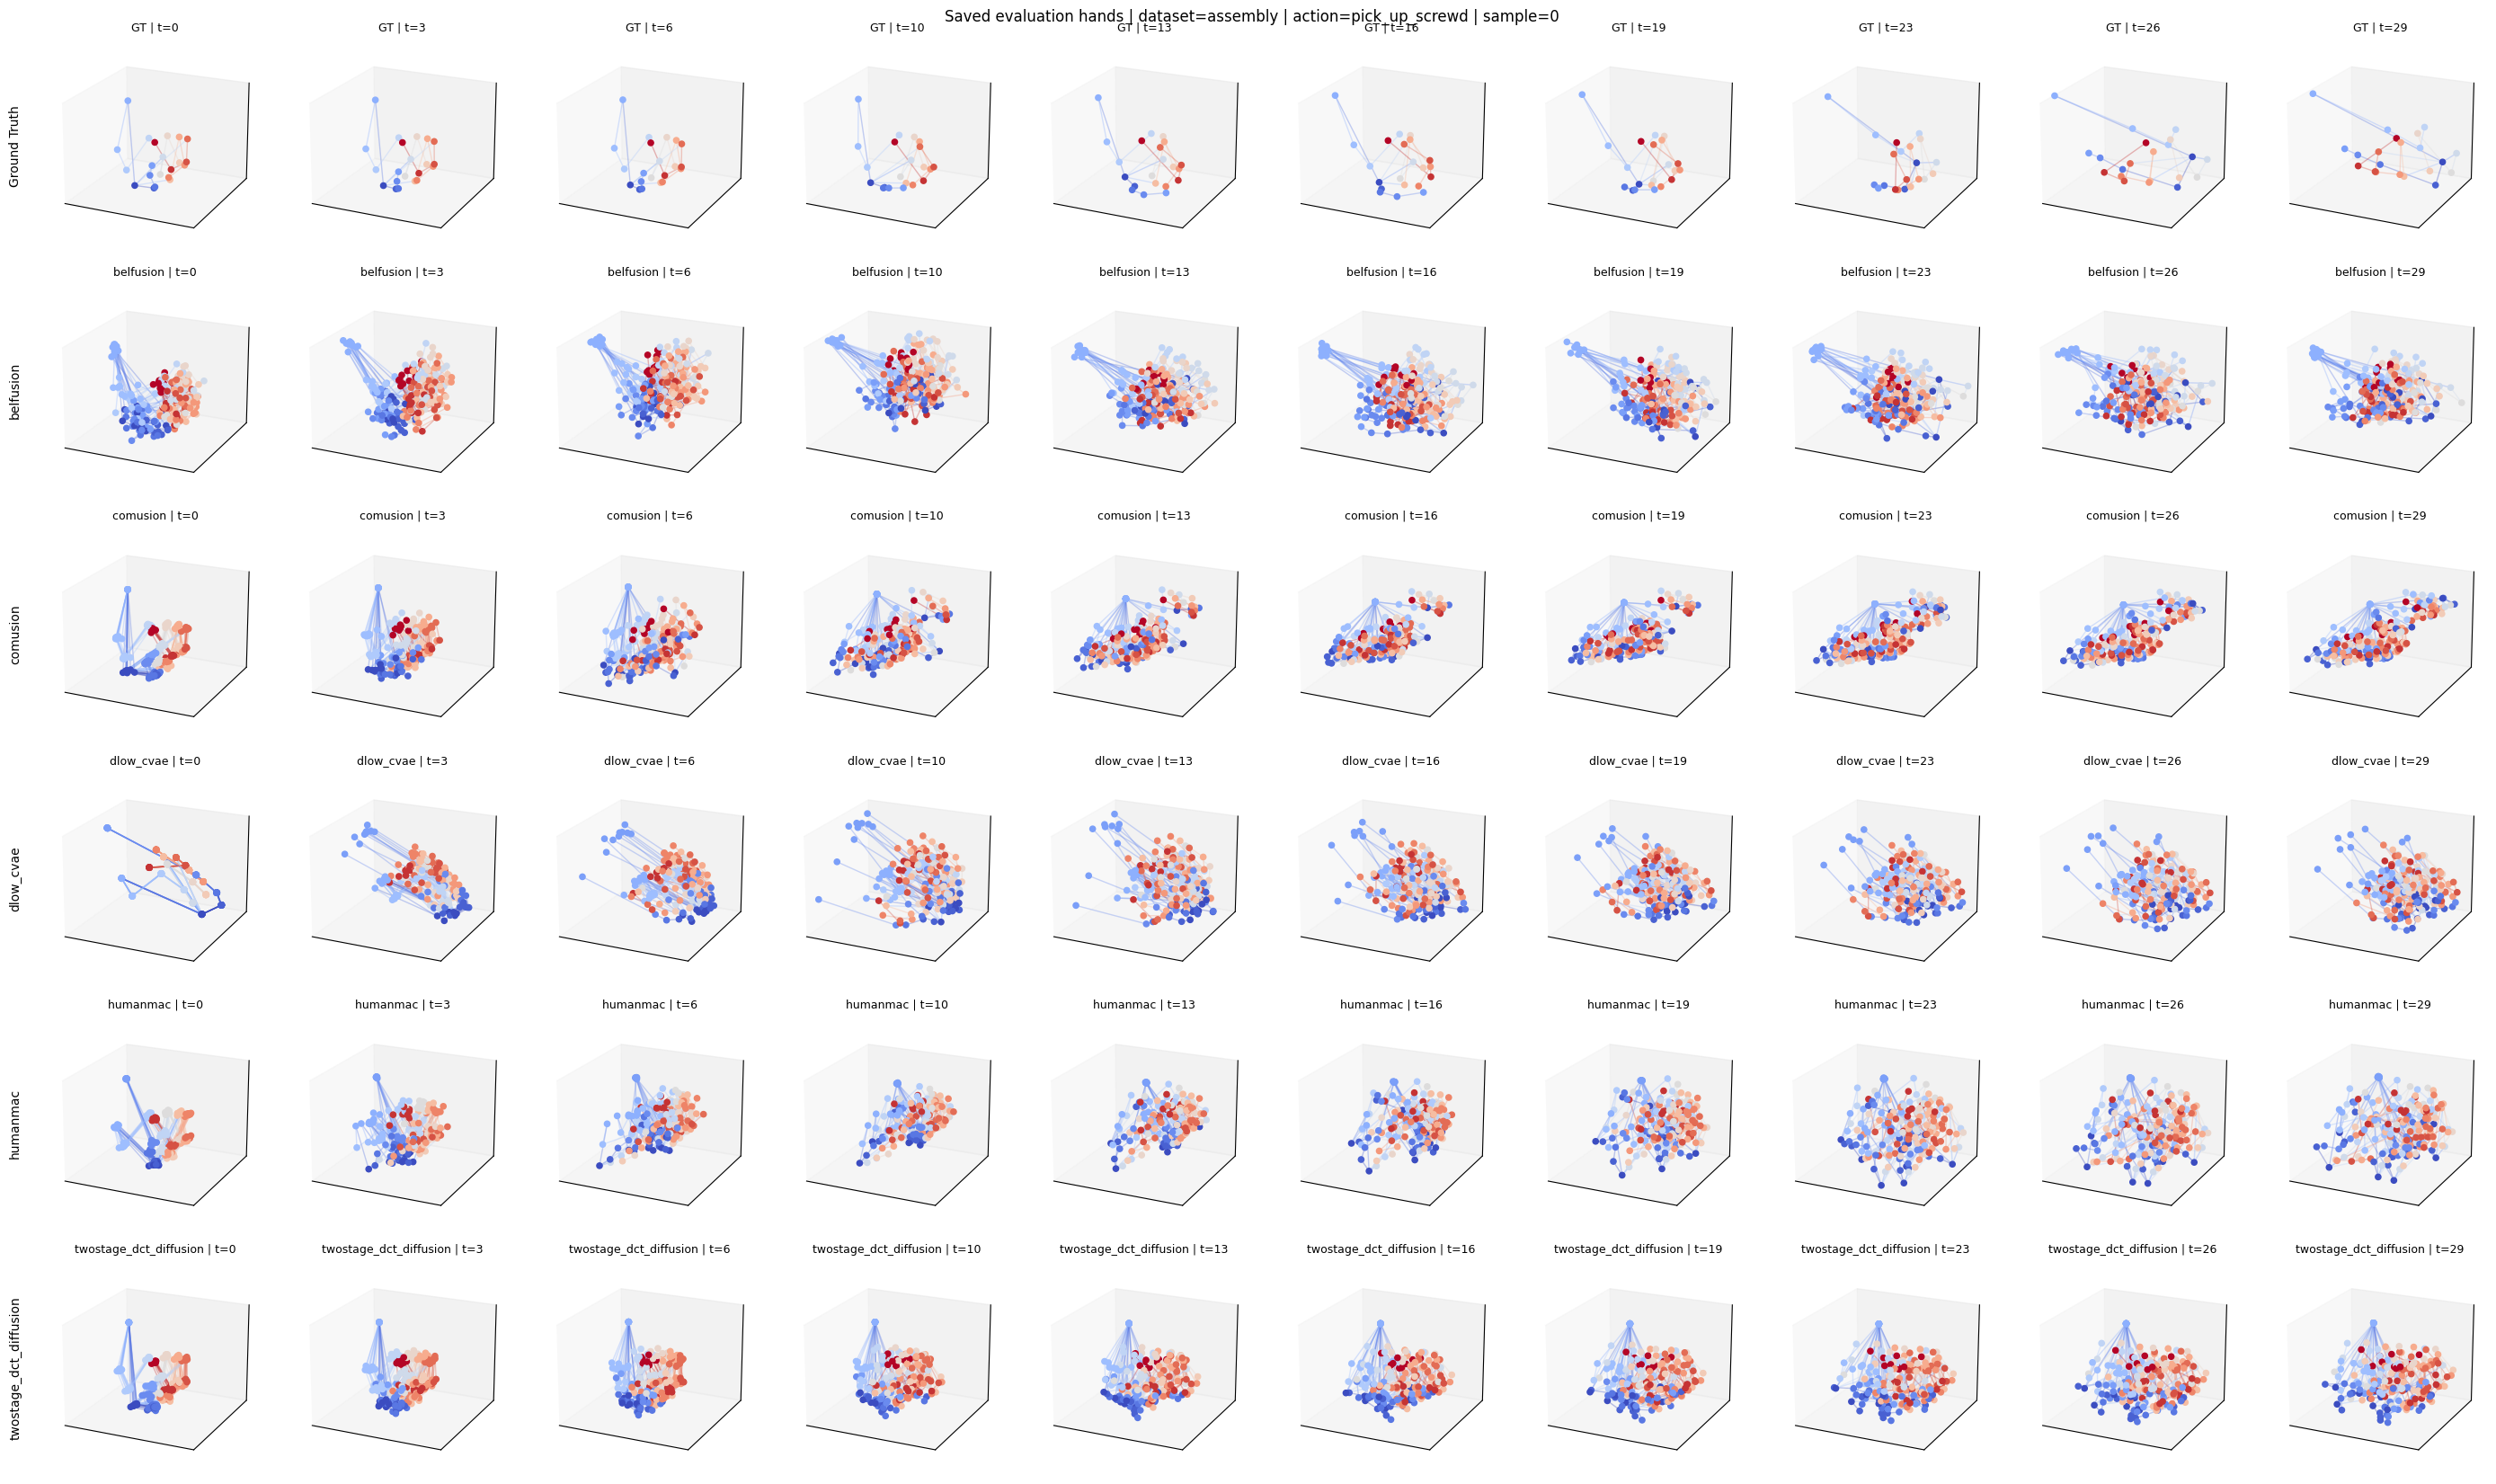

In [ ]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path('/home/fagnelli/diffusion_hands')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from common.dataset_graphs import get_root_first_single_hand_graph, resolve_local_hand_graph_metadata

EVAL_SAMPLES_ROOT = Path('/home/fagnelli/diffusion_hands/out/diffusion_hands_runs')


def list_saved_eval_sample_files(root=EVAL_SAMPLES_ROOT):
    return sorted(root.glob('**/eval_samples.npz'))


def load_saved_eval_samples(npz_path):
    data = np.load(npz_path, allow_pickle=True)
    payload = {key: data[key] for key in data.files if key != 'metadata_json'}
    metadata = {}
    if 'metadata_json' in data.files:
        metadata = json.loads(str(data['metadata_json']))
    pred = payload.get('pred')
    pred_all = payload.get('pred_all')
    if pred is not None and pred_all is not None and pred_all.ndim == 5 and pred.ndim == 4:
        if pred_all.shape[0] != pred.shape[0] and pred_all.shape[1] == pred.shape[0]:
            payload['pred_all'] = np.transpose(pred_all, (1, 0, 2, 3, 4))
    return payload, metadata


def collect_saved_eval_samples(root=EVAL_SAMPLES_ROOT, dataset=None, action_filter=None):
    bundles = []
    for npz_path in list_saved_eval_sample_files(root):
        payload, metadata = load_saved_eval_samples(npz_path)
        meta_dataset = metadata.get('dataset')
        meta_action = metadata.get('action_filter', '') or 'all'
        if dataset is not None and meta_dataset != dataset:
            continue
        if action_filter is not None and meta_action != action_filter:
            continue
        bundles.append({'path': npz_path, 'payload': payload, 'metadata': metadata})
    return bundles


def _select_latest_bundle_per_model(bundles):
    by_model = {}
    for bundle in bundles:
        model_name = bundle['metadata'].get('model', bundle['path'].parent.name)
        current = by_model.get(model_name)
        if current is None or bundle['path'].stat().st_mtime > current['path'].stat().st_mtime:
            by_model[model_name] = bundle
    return dict(sorted(by_model.items()))


def _sample_timestep_indices(num_frames, max_timesteps=10):
    max_timesteps = max(1, min(int(max_timesteps), int(num_frames)))
    if max_timesteps == num_frames:
        return np.arange(num_frames, dtype=int)
    return np.unique(np.round(np.linspace(0, num_frames - 1, max_timesteps)).astype(int))


def _hand_edges_for_dataset(dataset_name):
    if dataset_name is None:
        dataset_name = 'assembly'
    metadata = resolve_local_hand_graph_metadata(str(dataset_name).lower())
    return [tuple(edge) for edge in metadata.get('links', ())]


def _root_first_hand_edges_for_dataset(dataset_name):
    if dataset_name is None:
        dataset_name = 'assembly'
    metadata = get_root_first_single_hand_graph(str(dataset_name).lower())
    return [tuple(edge) for edge in metadata.get('links', ())]


def _model_uses_root_first_graph(model_name):
    model_name = str(model_name or '').lower()
    return model_name in {'dlow_cvae', 'humanmac'}


def _prepare_hands_for_plot(hands_frame, model_name, dataset_name, hand_edges=None):
    hands_frame = np.asarray(hands_frame)
    if hands_frame.ndim == 2:
        hands_frame = hands_frame[None, ...]

    use_root_first = _model_uses_root_first_graph(model_name)
    if hand_edges is None:
        hand_edges = _root_first_hand_edges_for_dataset(dataset_name) if use_root_first else _hand_edges_for_dataset(dataset_name)

    if use_root_first and hands_frame.shape[-2] == 20:
        root = np.zeros(hands_frame.shape[:-2] + (1, hands_frame.shape[-1]), dtype=hands_frame.dtype)
        hands_frame = np.concatenate([root, hands_frame], axis=-2)

    return hands_frame, hand_edges


def _compute_axis_box(points):
    points = np.asarray(points)
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    center = 0.5 * (mins + maxs)
    radius = max(1e-6, 0.5 * np.max(maxs - mins))
    return center, radius


def _set_equal_axes(ax, points=None, axis_box=None):
    if axis_box is None:
        if points is None:
            raise ValueError('Either points or axis_box must be provided.')
        axis_box = _compute_axis_box(points)
    center, radius = axis_box
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)


def _downsample_hands(hands_frame, max_hands_per_subplot=None):
    hands_frame = np.asarray(hands_frame)
    if hands_frame.ndim == 2:
        return hands_frame[None, ...]
    if max_hands_per_subplot is None:
        return hands_frame
    max_hands_per_subplot = max(1, int(max_hands_per_subplot))
    if hands_frame.shape[0] <= max_hands_per_subplot:
        return hands_frame
    keep_idx = np.linspace(0, hands_frame.shape[0] - 1, max_hands_per_subplot).round().astype(int)
    keep_idx = np.unique(keep_idx)
    return hands_frame[keep_idx]


def _find_best_candidate_index(pred_all_sample, target_sample, model_name=None, dataset_name=None):
    pred_all_sample, _ = _prepare_hands_for_plot(pred_all_sample, model_name=model_name, dataset_name=dataset_name)
    target_sample, _ = _prepare_hands_for_plot(target_sample, model_name=model_name, dataset_name=dataset_name)
    pred_all_sample = np.asarray(pred_all_sample)
    target_sample = np.asarray(target_sample)
    if pred_all_sample.ndim < 4:
        return None
    diffs = pred_all_sample - target_sample[None, ...]
    distances = np.linalg.norm(diffs, axis=-1).mean(axis=tuple(range(1, diffs.ndim - 1)))
    return int(np.argmin(distances))


def _plot_hand_frame(ax, hands_frame, hand_edges, title=None, hand_cmap=None, max_hands_per_subplot=32, fixed_color=None, best_idx=None, axis_box=None):
    hands_frame = np.asarray(hands_frame)
    hands_frame = _downsample_hands(hands_frame, max_hands_per_subplot=max_hands_per_subplot)
    if hand_cmap is None:
        hand_cmap = plt.cm.autumn

    if fixed_color is not None:
        hand_styles = [{'color': fixed_color, 'alpha': 1.0, 'linewidth': 1.5, 'size': 24}] * hands_frame.shape[0]
    elif hands_frame.shape[0] == 1:
        hand_styles = [{'color': 'tab:blue', 'alpha': 1.0, 'linewidth': 1.5, 'size': 24}]
    else:
        hand_colors = hand_cmap(np.linspace(0.0, 1.0, hands_frame.shape[0]))
        hand_styles = [
            {'color': hand_colors[idx], 'alpha': 0.45, 'linewidth': 1.1, 'size': 18}
            for idx in range(hands_frame.shape[0])
        ]
        if best_idx is not None and 0 <= int(best_idx) < hands_frame.shape[0]:
            hand_styles[int(best_idx)] = {'color': 'tab:blue', 'alpha': 1.0, 'linewidth': 2.2, 'size': 28}

    draw_order = [idx for idx in range(hands_frame.shape[0]) if idx != best_idx]
    if best_idx is not None and 0 <= int(best_idx) < hands_frame.shape[0]:
        draw_order.append(int(best_idx))

    for hand_idx in draw_order:
        hand = hands_frame[hand_idx]
        hand_style = hand_styles[hand_idx]
        valid_edges = [(i, j) for i, j in hand_edges if i < hand.shape[0] and j < hand.shape[0]]
        for i, j in valid_edges:
            ax.plot(
                [hand[i, 0], hand[j, 0]],
                [hand[i, 1], hand[j, 1]],
                [hand[i, 2], hand[j, 2]],
                color=hand_style['color'],
                alpha=hand_style['alpha'],
                linewidth=hand_style['linewidth'],
            )
        ax.scatter(hand[:, 0], hand[:, 1], hand[:, 2], color=hand_style['color'], alpha=hand_style['alpha'], s=hand_style['size'], depthshade=False)

    all_points = hands_frame.reshape(-1, 3)
    _set_equal_axes(ax, all_points, axis_box=axis_box)
    ax.view_init(elev=20, azim=-65)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    if title:
        ax.set_title(title, fontsize=9)


def visualize_saved_eval_grid(sample_idx=0, dataset=None, action_filter=None, max_timesteps=10, model_order=None, max_hands_per_subplot=32):
    bundles = collect_saved_eval_samples(dataset=dataset, action_filter=action_filter)
    bundles_by_model = _select_latest_bundle_per_model(bundles)
    if not bundles_by_model:
        raise ValueError('No saved eval samples found for the requested filters.')

    if model_order is None:
        model_names = list(bundles_by_model.keys())
    else:
        model_names = [name for name in model_order if name in bundles_by_model]

    first_bundle = bundles_by_model[model_names[0]]
    first_payload = first_bundle['payload']
    if sample_idx >= len(first_payload['target']):
        raise IndexError(f'sample_idx={sample_idx} out of range for {len(first_payload["target"])} saved samples.')

    dataset_name = first_bundle['metadata'].get('dataset', dataset or 'assembly')
    hand_edges_gt = _hand_edges_for_dataset(dataset_name)

    num_future_frames = first_payload['target'].shape[1]
    timestep_indices = _sample_timestep_indices(num_future_frames, max_timesteps=max_timesteps)
    num_rows = 1 + len(model_names)
    num_cols = len(timestep_indices)
    fig, axes = plt.subplots(
        num_rows,
        num_cols,
        figsize=(2.8 * num_cols, 2.8 * num_rows),
        subplot_kw={'projection': '3d'},
        squeeze=False,
    )

    gt_hands = first_payload['target'][sample_idx]
    gt_axis_boxes = {}
    for col_idx, frame_idx in enumerate(timestep_indices):
        ax = axes[0, col_idx]
        gt_frame, gt_edges = _prepare_hands_for_plot(gt_hands[frame_idx], model_name='ground_truth', dataset_name=dataset_name, hand_edges=hand_edges_gt)
        gt_axis_boxes[int(frame_idx)] = _compute_axis_box(gt_frame.reshape(-1, 3))
        _plot_hand_frame(ax, gt_frame, gt_edges, title=f'GT | t={frame_idx}', max_hands_per_subplot=max_hands_per_subplot, fixed_color='tab:blue', axis_box=gt_axis_boxes[int(frame_idx)])

    for row_idx, model_name in enumerate(model_names, start=1):
        payload = bundles_by_model[model_name]['payload']
        model_dataset_name = bundles_by_model[model_name]['metadata'].get('dataset', dataset_name)
        hand_edges_model = _hand_edges_for_dataset(model_dataset_name)
        pred_all = payload.get('pred_all')
        pred = payload['pred']
        best_idx = None
        if pred_all is not None:
            best_idx = _find_best_candidate_index(pred_all[sample_idx], payload['target'][sample_idx], model_name=model_name, dataset_name=model_dataset_name)
        for col_idx, frame_idx in enumerate(timestep_indices):
            ax = axes[row_idx, col_idx]
            if pred_all is not None:
                hands_frame = pred_all[sample_idx, :, frame_idx]
            else:
                hands_frame = pred[sample_idx, frame_idx][None, ...]
            hands_frame, hand_edges_model = _prepare_hands_for_plot(hands_frame, model_name=model_name, dataset_name=model_dataset_name, hand_edges=hand_edges_model)
            title = f'{model_name} | t={frame_idx}'
            _plot_hand_frame(ax, hands_frame, hand_edges_model, title=title, max_hands_per_subplot=max_hands_per_subplot, best_idx=best_idx, axis_box=gt_axis_boxes[int(frame_idx)])

    row_labels = ['Ground Truth', *model_names]
    for row_idx, row_label in enumerate(row_labels):
        axes[row_idx, 0].text2D(-0.15, 0.5, row_label, transform=axes[row_idx, 0].transAxes, rotation=90, va='center', ha='center', fontsize=10)

    action_name = first_bundle['metadata'].get('action_filter', action_filter or '') or 'all'
    fig.suptitle(f'Saved evaluation hands | dataset={dataset_name} | action={action_name} | sample={sample_idx}')
    plt.tight_layout()
    plt.show()


saved_eval_files = list_saved_eval_sample_files()
print(f'Found {len(saved_eval_files)} eval sample bundles under {EVAL_SAMPLES_ROOT}')
for path in saved_eval_files[:10]:
    print(path)

# Example:
# visualize_saved_eval_grid(sample_idx=0, dataset='assembly', action_filter='pick_up_screwd', max_timesteps=10, max_hands_per_subplot=16)
